# Model Development

| # | Stage | Description |
|---|---|---|
| 1 | Load Processed Data | Load X_processed.csv and y_processed.csv |
| 2 | Train-Test Split | 80/20 stratified split |
| 3 | Handle Class Imbalance | SMOTE oversampling on training set |
| 4 | Train Multiple Models | LR, DT, RF, GBM, XGBoost |
| 5 | Evaluate & Compare | Accuracy, Precision, Recall, F1, AUC-ROC |
| 6 | Confusion Matrices | Visual comparison |
| 7 | ROC Curves | AUC comparison |
| 8 | Feature Importance | Best model feature ranking |
| 9 | Save Best Model | Export .pkl for API serving |

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Load processed data
X = pd.read_csv('../model/X_processed.csv')
y = pd.read_csv('../model/y_processed.csv').squeeze()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nClass distribution:')
print(y.value_counts())
print(f'\nFeatures: {list(X.columns)}')

X shape: (12205, 21)
y shape: (12205,)

Class distribution:
Revenue
0    10297
1     1908
Name: count, dtype: int64

Features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'Weekend', 'Month_Num', 'Visitor_New_Visitor', 'Visitor_Returning_Visitor', 'Total_Duration', 'Total_Pages', 'Engagement_Score', 'Avg_Time_Per_Page']


## 2. Train-Test Split (Stratified 80/20)

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('=== Train-Test Split ===')
print(f'Training set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set     : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nTraining class distribution:')
print(y_train.value_counts())
print(f'\nTest class distribution:')
print(y_test.value_counts())

=== Train-Test Split ===
Training set : 9764 samples (80.0%)
Test set     : 2441 samples (20.0%)

Training class distribution:
Revenue
0    8238
1    1526
Name: count, dtype: int64

Test class distribution:
Revenue
0    2059
1     382
Name: count, dtype: int64


## 3. Handle Class Imbalance — SMOTE

=== SMOTE: Handling Class Imbalance ===
Before SMOTE — Training set:
  No Purchase (0): 8238
  Purchase    (1): 1526

After SMOTE — Training set:
  No Purchase (0): 8238
  Purchase    (1): 8238
  Total samples  : 16476


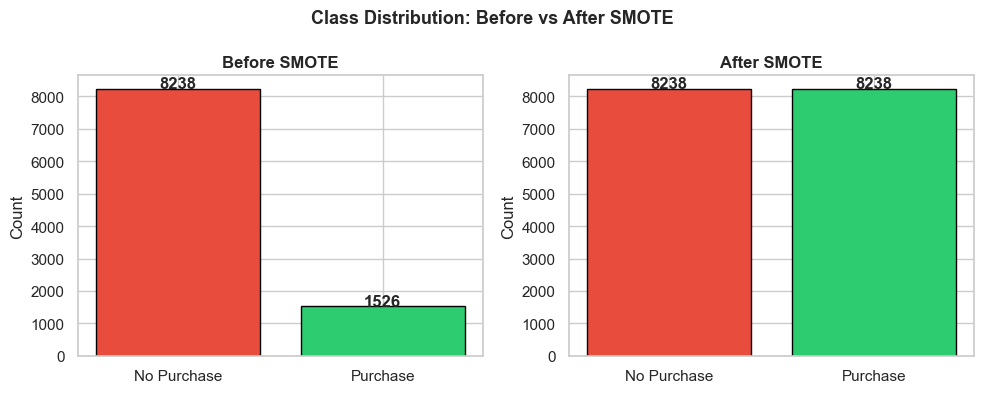

In [3]:
print('=== SMOTE: Handling Class Imbalance ===')
print(f'Before SMOTE — Training set:')
print(f'  No Purchase (0): {(y_train == 0).sum()}')
print(f'  Purchase    (1): {(y_train == 1).sum()}')

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'\nAfter SMOTE — Training set:')
print(f'  No Purchase (0): {(y_train_sm == 0).sum()}')
print(f'  Purchase    (1): {(y_train_sm == 1).sum()}')
print(f'  Total samples  : {len(X_train_sm)}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#e74c3c', '#2ecc71']

before = y_train.value_counts()
axes[0].bar(['No Purchase', 'Purchase'], before.values, color=colors, edgecolor='black')
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

after = pd.Series(y_train_sm).value_counts()
axes[1].bar(['No Purchase', 'Purchase'], after.values, color=colors, edgecolor='black')
axes[1].set_title('After SMOTE', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution: Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Train Multiple Models

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# Try XGBoost if available
try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(
        n_estimators=100, use_label_encoder=False,
        eval_metric='logloss', random_state=42, n_jobs=-1
    )
    print('XGBoost available — included in model comparison.')
except ImportError:
    print('XGBoost not installed — skipping. (pip install xgboost to include)')

print(f'\nModels to train: {list(models.keys())}')
print('Training on SMOTE-balanced dataset...')

XGBoost available — included in model comparison.

Models to train: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']
Training on SMOTE-balanced dataset...


In [5]:
trained_models = {}
results = []

for name, model in models.items():
    print(f'Training: {name}...', end=' ')
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1 Score':  round(f1_score(y_test, y_pred), 4),
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob), 4),
    })
    print('Done')

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False).reset_index(drop=True)
print('\nAll models trained successfully.')

Training: Logistic Regression... Done
Training: Decision Tree... Done
Training: Random Forest... Done
Training: Gradient Boosting... Done
Training: XGBoost... Done

All models trained successfully.


## 5. Model Comparison

=== MODEL COMPARISON ===
              Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
  Gradient Boosting    0.8902     0.6239  0.7513    0.6817   0.9339
      Random Forest    0.8869     0.6147  0.7435    0.6730   0.9226
            XGBoost    0.8943     0.6667  0.6492    0.6578   0.9212
      Decision Tree    0.8685     0.5590  0.7565    0.6429   0.8648
Logistic Regression    0.8677     0.5566  0.7592    0.6423   0.9032


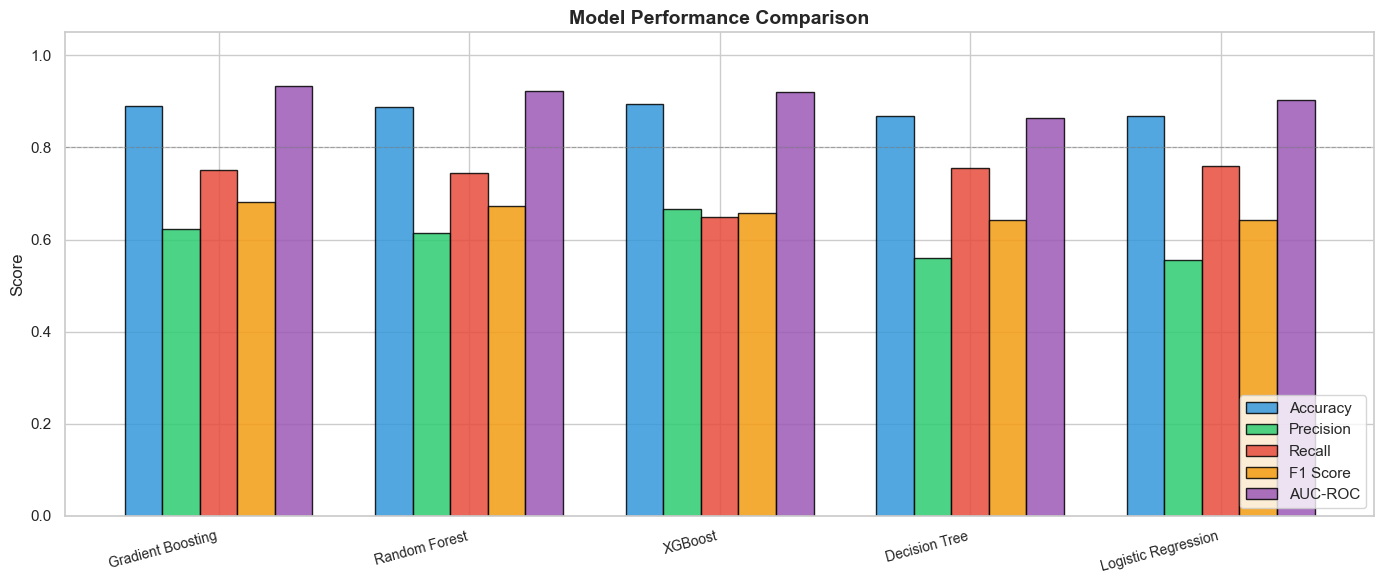

In [6]:
print('=== MODEL COMPARISON ===')
print(results_df.to_string(index=False))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
x = np.arange(len(results_df))
width = 0.15
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(14, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric,
           color=colors_bar[i], edgecolor='black', alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

## 6. Confusion Matrices

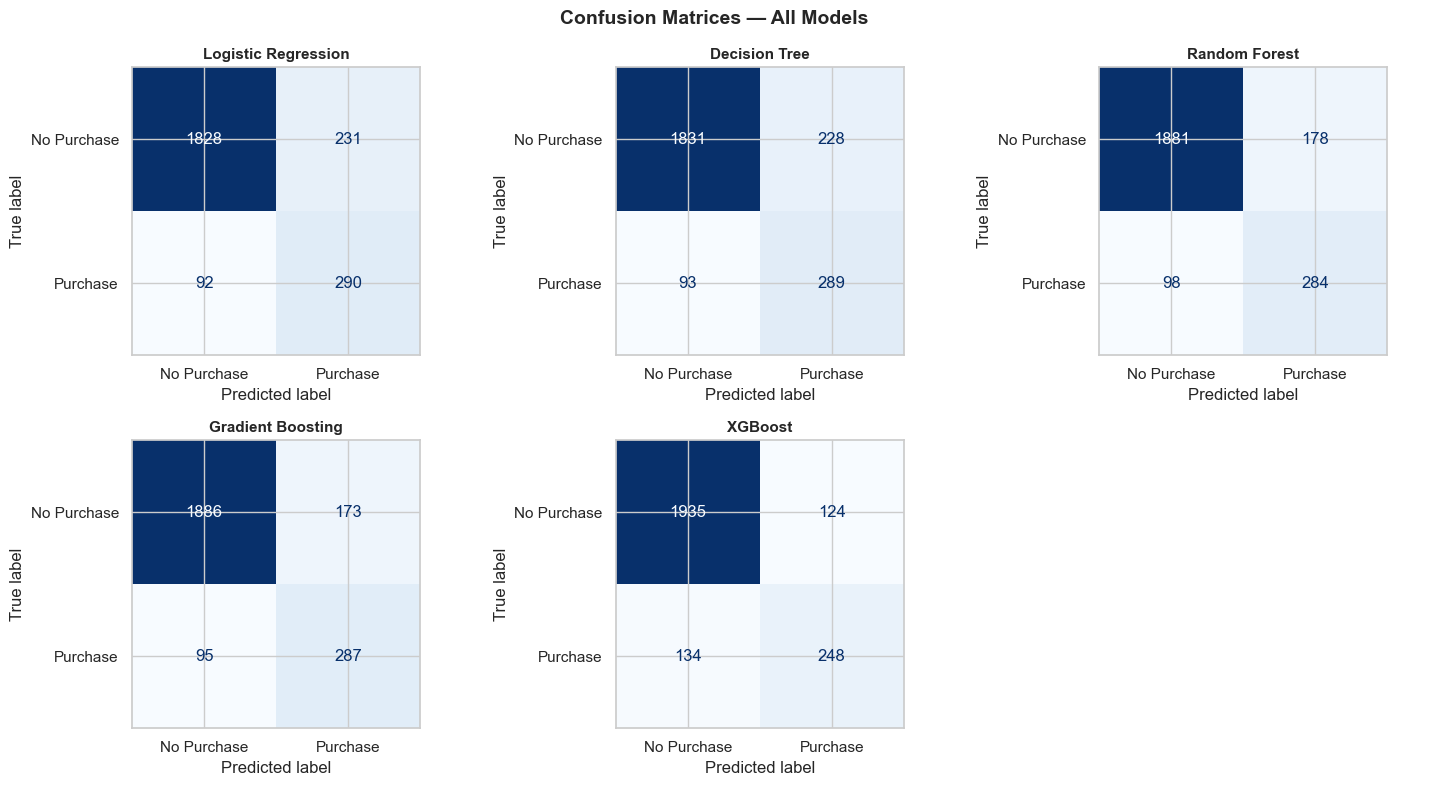

In [7]:
n_models = len(trained_models)
ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Purchase', 'Purchase'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontweight='bold', fontsize=11)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. ROC Curves

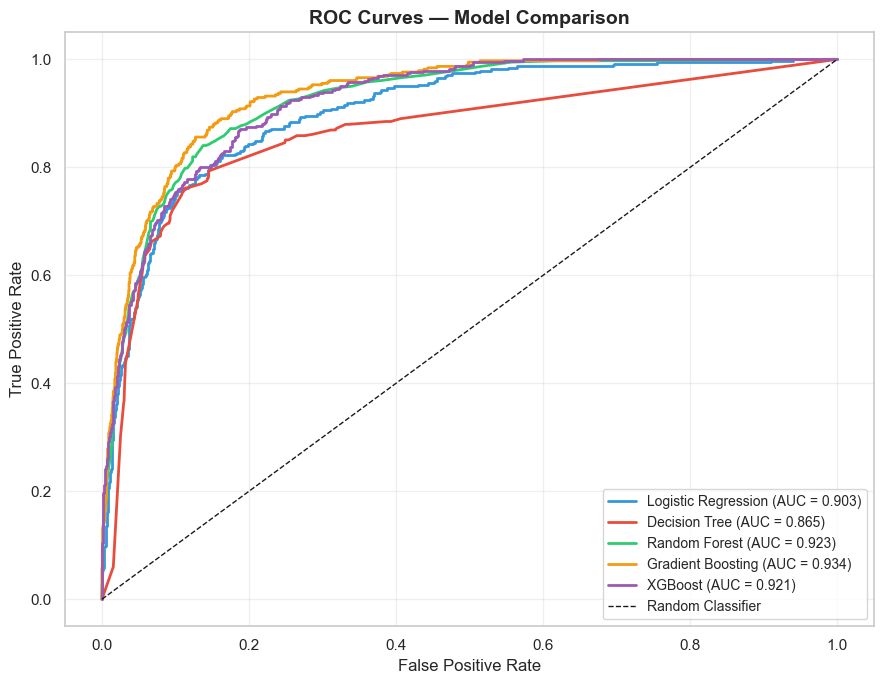

In [8]:
plt.figure(figsize=(9, 7))
line_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for i, (name, model) in enumerate(trained_models.items()):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})',
             color=line_colors[i % len(line_colors)], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Cross-Validation (Best Model)

In [9]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f'=== Best Model: {best_model_name} ===')
print(f'Selected based on highest F1 Score: {results_df.iloc[0]["F1 Score"]}')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1  = cross_val_score(best_model, X, y, cv=skf, scoring='f1',       n_jobs=-1)
cv_auc = cross_val_score(best_model, X, y, cv=skf, scoring='roc_auc',  n_jobs=-1)

print(f'\n5-Fold Cross-Validation Results:')
print(f'  F1 Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}  (folds: {np.round(cv_f1, 4)})')
print(f'  AUC-ROC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}  (folds: {np.round(cv_auc, 4)})')

# Full classification report
y_pred_best = best_model.predict(X_test)
print(f'\nClassification Report — {best_model_name}:')
print(classification_report(y_test, y_pred_best, target_names=['No Purchase', 'Purchase']))

=== Best Model: Gradient Boosting ===
Selected based on highest F1 Score: 0.6817

5-Fold Cross-Validation Results:
  F1 Score : 0.6526 ± 0.0092  (folds: [0.659  0.6491 0.6629 0.6553 0.6365])
  AUC-ROC  : 0.9309 ± 0.0071  (folds: [0.9359 0.9326 0.933  0.9171 0.936 ])

Classification Report — Gradient Boosting:
              precision    recall  f1-score   support

 No Purchase       0.95      0.92      0.93      2059
    Purchase       0.62      0.75      0.68       382

    accuracy                           0.89      2441
   macro avg       0.79      0.83      0.81      2441
weighted avg       0.90      0.89      0.89      2441



## 9. Feature Importance

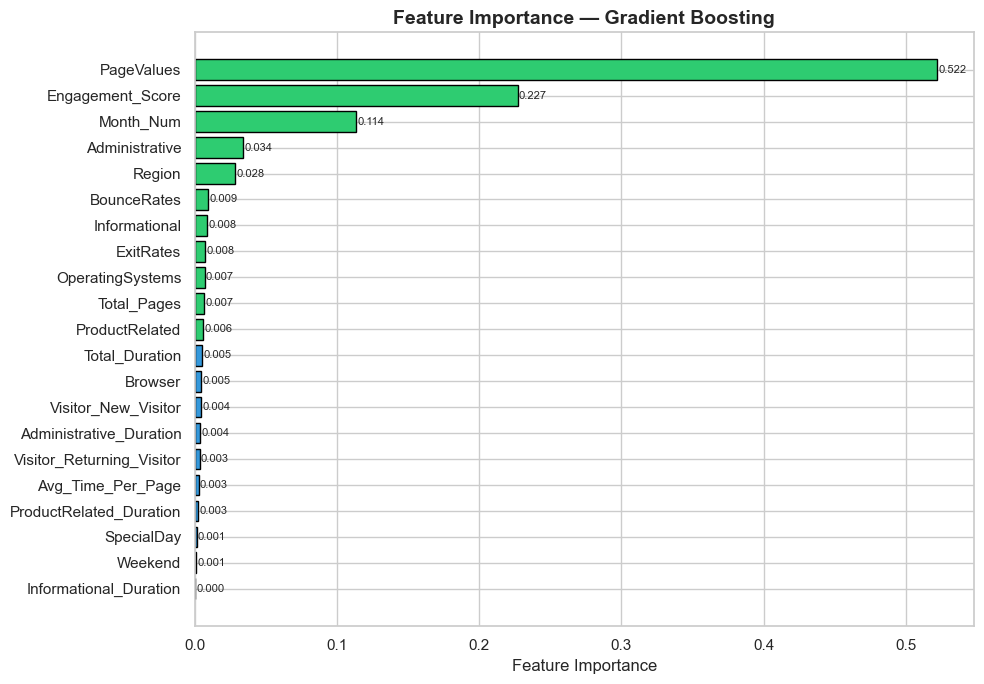

Top 5 most important features:
PageValues          0.521699
Engagement_Score    0.226958
Month_Num           0.113766
Administrative      0.034164
Region              0.028468


In [10]:
# Feature importance (tree-based models have feature_importances_)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(10, 7))
    colors_imp = ['#2ecc71' if v >= importances.median() else '#3498db' for v in importances.values]
    bars = plt.barh(importances.index, importances.values, color=colors_imp, edgecolor='black')
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title(f'Feature Importance — {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    for bar, val in zip(bars, importances.values):
        plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    print('Top 5 most important features:')
    print(importances.head(5).to_string())
elif hasattr(best_model, 'coef_'):
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X.columns)
    importances = importances.sort_values(ascending=False)
    plt.figure(figsize=(10, 7))
    plt.barh(importances.index, importances.values, color='steelblue', edgecolor='black')
    plt.xlabel('|Coefficient|', fontsize=12)
    plt.title(f'Feature Coefficients — {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_model_name} does not expose feature importances.')

## 10. Save Best Model

In [11]:
# Save best model
joblib.dump(best_model, '../model/best_model.pkl')

# Save model metadata
model_info = {
    'model_name':    best_model_name,
    'features':      list(X.columns),
    'n_features':    X.shape[1],
    'accuracy':      float(results_df.iloc[0]['Accuracy']),
    'precision':     float(results_df.iloc[0]['Precision']),
    'recall':        float(results_df.iloc[0]['Recall']),
    'f1_score':      float(results_df.iloc[0]['F1 Score']),
    'auc_roc':       float(results_df.iloc[0]['AUC-ROC']),
}

import json
with open('../model/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print('=== MODEL SAVED ===')
print(f'  best_model.pkl   → trained {best_model_name}')
print(f'  model_info.json  → metadata')
print(f'  scaler.pkl       → already saved from feature engineering')

print(f'\n=== FINAL MODEL SUMMARY ===')
print(f'  Selected Model : {best_model_name}')
print(f'  Accuracy       : {model_info["accuracy"]}')
print(f'  Precision      : {model_info["precision"]}')
print(f'  Recall         : {model_info["recall"]}')
print(f'  F1 Score       : {model_info["f1_score"]}')
print(f'  AUC-ROC        : {model_info["auc_roc"]}')
print(f'  Features used  : {model_info["n_features"]}')


=== MODEL SAVED ===
  best_model.pkl   → trained Gradient Boosting
  model_info.json  → metadata
  scaler.pkl       → already saved from feature engineering

=== FINAL MODEL SUMMARY ===
  Selected Model : Gradient Boosting
  Accuracy       : 0.8902
  Precision      : 0.6239
  Recall         : 0.7513
  F1 Score       : 0.6817
  AUC-ROC        : 0.9339
  Features used  : 21
